In [1]:
import os
# CRITICAL FIX: Prevents the C++ threading clash between PyTorch and Gurobi 
# that causes silent kernel crashes.
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import gurobipy as gp
from gurobipy import GRB
import cvxpy as cp
import warnings

warnings.filterwarnings("ignore")

# Import from the src folder package
from src.data_utils import parse_file_data, get_old_voltages
from src.formulation import generate_training_data
from src.cvxpy_layer import build_diffopt_qcac_layer

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load the grid
file_name = 'case14'
file_path = f'data/{file_name}.m'  # Ensure case14.m is in your src folder or update path
data = parse_file_data(file_path)
num_buses = len(data.buses)
num_gens = len(data.gens)
print(f"Loaded Grid: {num_buses} Buses, {num_gens} Generators")
# ════════════════════════════════════════════
# GLOBAL DEMAND SCALE RANGE
# Change these two numbers to shift ALL training/test data at once.
# ════════════════════════════════════════════
# Number of learned integer cuts (change here only)
CUT_NUM   = 3     # ← change this to use a different number of cuts

SCALE_MIN = 0.4   # minimum load multiplier
SCALE_MAX = 1.3   # maximum load multiplier


Loaded Grid: 14 Buses, 5 Generators


In [2]:
# -----------------------------------------------------------------
# CELL 2: Dataset Generation & Caching
# -----------------------------------------------------------------
import os
import torch
import numpy as np
from src.formulation import build_mp_ac_uc_rectangular

# Create a directory to store the generated data
os.makedirs('data', exist_ok=True)
sup_data_path = f'data/supervised_data_{file_name}.pt'
unsup_data_path = f'data/unsupervised_data_{file_name}.pt'

# -----------------------------------------------------------------
# CHECK: Do the datasets already exist on disk?
# -----------------------------------------------------------------
if os.path.exists(sup_data_path) and os.path.exists(unsup_data_path):
    print("Found existing datasets on disk! Loading them instantly...")
    
    sup_dict = torch.load(sup_data_path)
    X_sup_t = sup_dict['X_sup_t']
    Y_u_sup_t = sup_dict['Y_u_sup_t']
    
    unsup_dict = torch.load(unsup_data_path)
    X_unsup_t = unsup_dict['X_unsup_t']
    
    print(f"Loaded! Supervised Samples: {len(X_sup_t)} | Unlabeled Samples: {len(X_unsup_t)}")

# -----------------------------------------------------------------
# GENERATE: If not, generate them and save to disk
# -----------------------------------------------------------------
else:
    print("No cached data found. Generating datasets from scratch...")
    
    # 1. Get initial warm-start voltages using a flat 1.0 load
    m_base = build_mp_ac_uc_rectangular(data, demand_curve=[1.0])
    m_base.setParam('OutputFlag', 0)
    m_base.optimize()
    vr_init, vi_init = get_old_voltages(m_base, data)

    # 2. Generate SUPERVISED Data (Phase 1)
    print("Generating Small Supervised Dataset (Exact MIQCQP Solutions)...")
    X_sup, Y_pg_sup, Y_u_sup = generate_training_data(
        data, vr_init, vi_init, n_samples=50, load_scale_min=SCALE_MIN, load_scale_max=SCALE_MAX
    )
    X_sup_t = torch.tensor(X_sup, dtype=torch.float32)
    Y_u_sup_t = torch.tensor(Y_u_sup, dtype=torch.float32)

    # 3. Generate UNLABELED Data (Phase 2) 
    print("Generating Unlabeled Dataset for Self-Supervised Fine-Tuning...")
    n_unlabeled = 150
    X_unsup = []
    
    # Extract base loads directly from the grid data
    base_pd = [data.loads[l]['pd'] for l in data.loads] * (num_buses // len(data.loads))
    base_demand = np.ones(num_buses * 2) * 0.5 
    
    for _ in range(n_unlabeled):
        scale = np.random.uniform(SCALE_MIN, SCALE_MAX)
        noise = np.random.normal(1.0, 0.05, num_buses * 2)
        X_unsup.append(base_demand * scale * noise)
        
    X_unsup_t = torch.tensor(np.array(X_unsup), dtype=torch.float32)

    print(f"Generation Complete! Supervised Samples: {len(X_sup_t)} | Unlabeled Samples: {len(X_unsup_t)}")
    
    # 4. Save the generated tensors to disk
    print("Saving datasets to 'data/' directory for future runs...")
    torch.save({'X_sup_t': X_sup_t, 'Y_u_sup_t': Y_u_sup_t}, sup_data_path)
    torch.save({'X_unsup_t': X_unsup_t}, unsup_data_path)
    print("Save successful!")

Found existing datasets on disk! Loading them instantly...
Loaded! Supervised Samples: 50 | Unlabeled Samples: 150


In [3]:
# # 1. Get initial warm-start voltages using a flat 1.0 load
# from src.formulation import build_mp_ac_uc_rectangular
# m_base = build_mp_ac_uc_rectangular(data, demand_curve=[1.0])
# m_base.setParam('OutputFlag', 0)
# m_base.optimize()
# vr_init, vi_init = get_old_voltages(m_base, data)

# # 2. Generate SUPERVISED Data (Phase 1) - Small dataset with exact answers
# print("Generating Small Supervised Dataset (Exact MIQCQP Solutions)...")
# # Note: generate_training_data adds the macro scale + micro noise we discussed!
# X_sup, Y_pg_sup, Y_u_sup = generate_training_data(
#     data, vr_init, vi_init, n_samples=50, load_scale_min=0.8, load_scale_max=1.2
# )
# X_sup_t = torch.tensor(X_sup, dtype=torch.float32)
# Y_u_sup_t = torch.tensor(Y_u_sup, dtype=torch.float32)

# # 3. Generate UNLABELED Data (Phase 2) - Demand profiles only
# print("Generating Unlabeled Dataset for Self-Supervised Fine-Tuning...")
# n_unlabeled = 150
# # We just need the inputs (Pd, Qd) for these. 
# # X_sup returns [pd_1, qd_1, pd_2, qd_2...]. We simulate random profiles:
# X_unsup = []
# base_pd = [data.loads[l]['pd'] for l in data.loads] * (num_buses // len(data.loads)) # Rough padding
# for _ in range(n_unlabeled):
#     scale = np.random.uniform(0.7, 1.3)
#     noise = np.random.normal(1.0, 0.05, num_buses * 2)
#     # Create a synthetic base demand vector and perturb it
#     base_demand = np.ones(num_buses * 2) * 0.5 
#     X_unsup.append(base_demand * scale * noise)
# X_unsup_t = torch.tensor(np.array(X_unsup), dtype=torch.float32)

# print(f"Supervised Samples: {len(X_sup_t)} | Unlabeled Samples: {len(X_unsup_t)}")

In [4]:
# -----------------------------------------------------------------
# CELL 3: The PyTorch Neural Network
# (Model class lives in src/model.py so parallel workers can import it)
# -----------------------------------------------------------------
from src.model import QCAC_Surrogate

model     = QCAC_Surrogate(num_buses, num_gens, num_cuts=CUT_NUM)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

print("Neural Network Architecture successfully initialized!")
print(model)


Neural Network Architecture successfully initialized!
QCAC_Surrogate(
  (trunk): Sequential(
    (0): Linear(in_features=28, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
  )
  (head_v): Linear(in_features=64, out_features=28, bias=True)
  (head_rho): Linear(in_features=64, out_features=1, bias=True)
  (head_cuts): Linear(in_features=64, out_features=18, bias=True)
  (head_u): Sequential(
    (0): Linear(in_features=64, out_features=5, bias=True)
    (1): Sigmoid()
  )
)


In [5]:
# -----------------------------------------------------------------
# CELL 4: Phase 1 - Supervised Pre-Training
# -----------------------------------------------------------------
print("--- Phase 1: Supervised Pre-Training (Behavioral Cloning) ---")

epochs_phase1 = 200
# Binary Cross Entropy to learn the 0/1 generator commitments
criterion_bce = nn.BCELoss()

# Keep track of losses for plotting later if desired
history_loss_u = []
history_loss_v = []

# Ensure the model is in training mode
model.train()

for epoch in range(epochs_phase1):
    optimizer.zero_grad()
    
    # Forward pass on the small, exact dataset
    u_pred, vr_base, vi_base, rho, A_cut, b_cut = model(X_sup_t)
    
    # -------------------------------------------------------------
    # LOSS 1: The Combinatorial Topology
    # Force the feature trunk to learn which generators turn on/off
    # -------------------------------------------------------------
    loss_u = criterion_bce(u_pred, Y_u_sup_t)
    
    # -------------------------------------------------------------
    # LOSS 2: The Voltage Anchor
    # Penalize the network if it guesses base voltages far from 
    # the standard 1.0 + 0.0j pu. This prevents CVXPY from crashing 
    # in Phase 2 due to insane Taylor expansion points.
    # -------------------------------------------------------------
    loss_v = torch.mean((vr_base - 1.0)**2) + torch.mean(vi_base**2)
    
    # Combine the losses (we lightly weight the voltage anchor)
    loss = loss_u + 0.1 * loss_v
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    # Store history
    history_loss_u.append(loss_u.item())
    history_loss_v.append(loss_v.item())
    
    if (epoch + 1) % 40 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs_phase1} | "
              f"Total Loss: {loss.item():.4f} | "
              f"Binary BCE: {loss_u.item():.4f} | "
              f"Voltage Anchor MSE: {loss_v.item():.4f}")

print("Phase 1 Complete. The Feature Trunk is awake and V_base is anchored.")

--- Phase 1: Supervised Pre-Training (Behavioral Cloning) ---
Epoch  40/200 | Total Loss: 0.0094 | Binary BCE: 0.0015 | Voltage Anchor MSE: 0.0789
Epoch  80/200 | Total Loss: 0.0034 | Binary BCE: 0.0005 | Voltage Anchor MSE: 0.0292
Epoch 120/200 | Total Loss: 0.0024 | Binary BCE: 0.0003 | Voltage Anchor MSE: 0.0213
Epoch 160/200 | Total Loss: 0.0015 | Binary BCE: 0.0002 | Voltage Anchor MSE: 0.0134
Epoch 200/200 | Total Loss: 0.0006 | Binary BCE: 0.0001 | Voltage Anchor MSE: 0.0052
Phase 1 Complete. The Feature Trunk is awake and V_base is anchored.


In [6]:
# -----------------------------------------------------------------
# CELL 5: Phase 2 - Self-Supervised DiffOpt Fine-Tuning  (PARALLEL)
# All multiprocessing code is in src/parallel_worker.py
# Change ANY of the values below directly in this cell.
# -----------------------------------------------------------------
import os
from src.parallel_worker import run_phase2_parallel

cvx_layer, b_idx, g_idx = build_diffopt_qcac_layer(data, num_cuts=CUT_NUM)

# ════════════════════════════════════════════════════════════
# ★  TUNING KNOBS  — edit these directly here  ★
# ════════════════════════════════════════════════════════════

LAMBDA_INTEGRALITY   = 5.0    # penalty pushing u toward 0 or 1  (higher = stricter)
SLACK_PENALTY_WEIGHT = 10.0    # penalty for violating learned cuts

EPOCHS       = 10              # Phase-2 training epochs
BATCH_SIZE   = 50             # samples per epoch  (use len(X_unsup_t) for final paper)
N_WORKERS    = 12             # parallel CPU processes (you have 12 cores)
SOLVER_EPS   = 1e-3           # SCS convergence tolerance (use 1e-3 for final paper)
SOLVER_ITERS = 8000           # SCS max iterations

PHASE2_LR    = 5e-3           # Phase-2 learning rate (KEEP MUCH LOWER than Phase-1 lr=0.005)
                              # Phase-1 Adam was tuned for per-sample noise; Phase-2 sends
                              # smooth batch gradients which would overshoot at lr=0.005.

# ════════════════════════════════════════════════════════════

run_phase2_parallel(
    model          = model,
    optimizer      = optimizer,
    X_unsup_t      = X_unsup_t,
    cvx_layer      = cvx_layer,
    data_file_path = os.path.abspath(file_path),
    num_buses      = num_buses,
    num_gens       = num_gens,
    num_cuts       = CUT_NUM,
    lambda_int     = LAMBDA_INTEGRALITY,
    slack_weight   = SLACK_PENALTY_WEIGHT,
    epochs         = EPOCHS,
    batch_size     = BATCH_SIZE,
    n_workers      = N_WORKERS,
    solver_eps     = SOLVER_EPS,
    solver_iters   = SOLVER_ITERS,
    phase2_lr      = PHASE2_LR,
)


Building Differentiable CVXPY Layer (This may take a moment)...
Layer compilation complete. DCP Compliant: TRUE
Phase 2 (FedAvg): 12 workers | 50 samples/epoch | eps=0.001 | lr=0.005
Epoch 1/10 | Solved 50/50 grids | Avg Loss: 48366.0214 | Time: 9.7s
Epoch 2/10 | Solved 50/50 grids | Avg Loss: 50817.1418 | Time: 10.9s
Epoch 3/10 | Solved 50/50 grids | Avg Loss: 44946.5743 | Time: 10.6s
Epoch 4/10 | Solved 50/50 grids | Avg Loss: 38710.5253 | Time: 9.8s
Epoch 5/10 | Solved 50/50 grids | Avg Loss: 34615.1013 | Time: 10.3s
Epoch 6/10 | Solved 50/50 grids | Avg Loss: 31332.4873 | Time: 10.9s
Epoch 7/10 | Solved 50/50 grids | Avg Loss: 26914.5802 | Time: 10.8s
Epoch 8/10 | Solved 50/50 grids | Avg Loss: 23648.2576 | Time: 10.6s
Epoch 9/10 | Solved 50/50 grids | Avg Loss: 21004.1625 | Time: 11.1s
Epoch 10/10 | Solved 50/50 grids | Avg Loss: 18904.9506 | Time: 10.4s
Phase 2 Complete! The Neural Network now understands continuous AC Physics.


In [7]:
# -----------------------------------------------------------------
# CELL 6: Phase 3 - Feasibility Restoration & Evaluation
# -----------------------------------------------------------------
print("--- Phase 3: Feasibility Restoration Projection ---")

def miqcqp_feasibility_restoration(data, u_frac, pd_dict, qd_dict, vr_base_val=None, vi_base_val=None):
    """
    Projects the continuous u_frac to the closest physically valid 
    integer combination using a CONVEX QCQP for speed and reliability.
    """
    from src.formulation import build_convex_ac_uc, _precompute_bus_connectivity
    
    # 1. Use the Convex relaxation for the projection (Faster + More robust)
    # If no base voltages are provided, we use flat 1.0 + 0.0j as a fallback
    v_r = vr_base_val if vr_base_val is not None else {str(i+1): 1.0 for i in range(len(data.buses))}
    v_i = vi_base_val if vi_base_val is not None else {str(i+1): 0.0 for i in range(len(data.buses))}
    
    m_proj = build_convex_ac_uc(data, v_r, v_i)
    m_proj.setParam('OutputFlag', 0)
    m_proj.setParam('TimeLimit', 10.0) 
    m_proj.setParam('MIPGap', 0.001) 
    
    # 2. Update loads for this specific test case
    for b_id in data.buses:
        m_proj._pbal[b_id, 1].RHS = pd_dict.get(b_id, 0.0)
        m_proj._qbal[b_id, 1].RHS = qd_dict.get(b_id, 0.0)
        
    # 3. Add L1-Norm objective: min \sum |u_int - u_frac|
    w = m_proj.addVars(list(data.gens.keys()), lb=0, vtype=GRB.CONTINUOUS)
    for idx, g_id in enumerate(sorted(list(data.gens.keys()))):
        m_proj.addConstr(w[g_id] >= m_proj._u[g_id, 1] - u_frac[idx])
        m_proj.addConstr(w[g_id] >= u_frac[idx] - m_proj._u[g_id, 1])
        
    m_proj.setObjective(gp.quicksum(w[g] for g in data.gens), GRB.MINIMIZE)
    m_proj.optimize()
    
    if m_proj.status in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
        u_final = [int(round(m_proj._u[g, 1].X)) for g in sorted(list(data.gens.keys()))]
        return u_final, "Optimal (Convex)"
    else:
        # Fallback heuristic if the convex solver fails
        print(f"      !!! Restoration failed with status {m_proj.status}")
        return np.round(u_frac).astype(int).tolist(), "Heuristic Rounded"

# =================================================================
# PIPELINE INFERENCE TEST
# =================================================================
model.eval()

# 1. Generate an unseen, low-load test profile to force generators to turn OFF
test_scale = np.random.uniform(SCALE_MIN, SCALE_MAX) 
test_pd = {}
test_qd = {}
test_input_list = []

for l_id, load in data.loads.items():
    b_id = load['load_bus']
    noise_p = np.random.normal(1.0, 0.05)
    noise_q = np.random.normal(1.0, 0.05)
    test_pd[b_id] = load['pd'] * test_scale * noise_p
    test_qd[b_id] = load['qd'] * test_scale * noise_q

for b_id in data.buses:
    test_input_list.extend([test_pd.get(b_id, 0.0), test_qd.get(b_id, 0.0)])

x_test = torch.tensor(test_input_list, dtype=torch.float32).unsqueeze(0)
pd_test_t = x_test[:, :num_buses]
qd_test_t = x_test[:, num_buses:]

print(f"1. Running Neural Network + CVXPY Forward Pass (Load Scale: {test_scale:.2f})...")
t0 = time.time()
with torch.no_grad():
    # NN Predicts parameters
    vr_base, vi_base, rho, A_cut, b_cut = model(x_test)
    
    # CVXPY applies physics
    try:
        # FIX 1: Catch all 6 variables (added s_cut)
        # FIX 2: Pass raw A_cut and b_cut without the taming hack
        u_relax, pg, qg, vr, vi, s_cut = cvx_layer(
            vr_base, vi_base, rho.squeeze(-1), A_cut, b_cut, pd_test_t, qd_test_t,
            solver_args={'max_iters': 10000, 'eps': 1e-3}
        )
        u_frac_np = u_relax.squeeze(0).numpy()
    except Exception as e:
        print(f"   -> CVXPY Layer Failed: {e}")
        u_frac_np = np.zeros(num_gens)
t_forward = time.time() - t0

print(f"   -> Continuous Commitment (u_relax): {np.round(u_frac_np, 3)}")
print(f"   -> Forward Pass Time: {t_forward:.3f}s")

print("\n2. Running L1-Norm Feasibility Restoration...")
t0 = time.time()

# Pass the predicted voltages from the NN to help the convex model solve even faster
vr_dict = {str(i+1): v for i, v in enumerate(vr_base.squeeze(0).numpy())}
vi_dict = {str(i+1): v for i, v in enumerate(vi_base.squeeze(0).numpy())}

u_final, status = miqcqp_feasibility_restoration(data, u_frac_np, test_pd, test_qd, vr_dict, vi_dict)
t_rest = time.time() - t0

print(f"   -> Final Integer Commitment: {u_final}")
print(f"   -> Restoration Status: {status}")
print(f"   -> Restoration Time: {t_rest:.3f}s")
print(f"\nTotal End-to-End Inference Time: {t_forward + t_rest:.3f}s")

--- Phase 3: Feasibility Restoration Projection ---
1. Running Neural Network + CVXPY Forward Pass (Load Scale: 0.74)...
   -> Continuous Commitment (u_relax): [0.845 1.    1.    0.843 1.   ]
   -> Forward Pass Time: 0.115s

2. Running L1-Norm Feasibility Restoration...
Set parameter Username
Academic license - for non-commercial use only - expires 2027-01-17
   -> Final Integer Commitment: [1, 1, 1, 1, 1]
   -> Restoration Status: Optimal (Convex)
   -> Restoration Time: 0.016s

Total End-to-End Inference Time: 0.131s


--- Starting Full Benchmark Evaluation ---
Found cached True MINLP benchmark data! Loading...
Set parameter NonConvex to value 2
Set parameter NonConvex to value 2aselines...
Set parameter NonConvex to value 2aselines...
Set parameter NonConvex to value 2
      !!! Restoration failed with status 12..
Set parameter NonConvex to value 2
Set parameter NonConvex to value 2aselines...
Set parameter NonConvex to value 2
Set parameter NonConvex to value 2aselines...
Set parameter NonConvex to value 2aselines...
      !!! Restoration failed with status 12
Set parameter NonConvex to value 2
      !!! Restoration failed with status 12..
Set parameter NonConvex to value 2
      !!! Restoration failed with status 12..
Set parameter NonConvex to value 2
Set parameter NonConvex to value 2aselines...
Set parameter NonConvex to value 2Baselines...
Set parameter NonConvex to value 2Baselines...
Set parameter NonConvex to value 2
Set parameter NonConvex to value 2Baselines...
Set parameter NonConvex to 

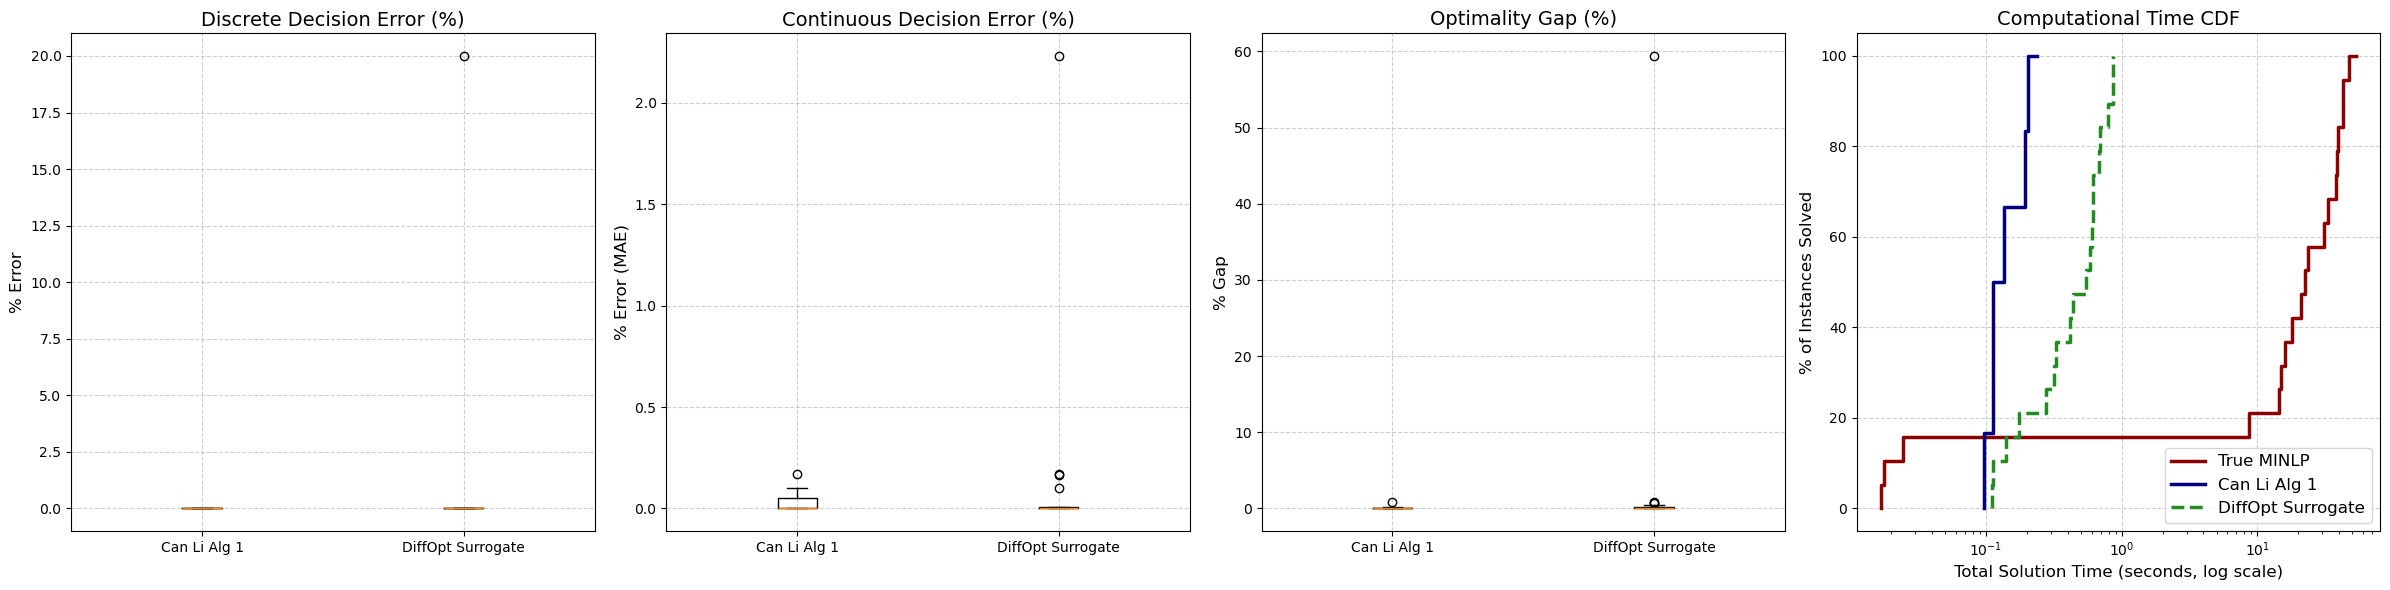

Total Notebook Cell Execution Time: 595.43 seconds


In [8]:
# -----------------------------------------------------------------
# CELL 7: Benchmark Evaluation & Final Paper Plots
# -----------------------------------------------------------------
import os
import torch
import time
import numpy as np
import matplotlib.pyplot as plt
from gurobipy import GRB
from src.formulation import build_single_ac_uc_rectangular, build_convex_ac_uc, build_mp_ac_uc_rectangular, _precompute_bus_connectivity
from src.data_utils import get_old_voltages

print("--- Starting Full Benchmark Evaluation ---")
overall_cell_start = time.time()

num_test_samples = 20 # Change to 100 for your final paper
# Changed filename to force a fresh dataset with the new Pmin and Fixed Cost physics!
benchmark_path = f'data/test_benchmark{file_name}.pt'

# Helper Function: Evaluate the TRUE cost and continuous Pg of a fixed binary decision
def evaluate_fixed_u(data, u_fixed, pd_dict, qd_dict):
    m_eval = build_single_ac_uc_rectangular(data)
    m_eval.setParam('OutputFlag', 0)
    m_eval.setParam('TimeLimit', 15.0) 
    
    for b_id in data.buses:
        m_eval._pbal[b_id, 1].RHS = pd_dict.get(b_id, 0.0)
        m_eval._qbal[b_id, 1].RHS = qd_dict.get(b_id, 0.0)
        
    for idx, g_id in enumerate(sorted(list(data.gens.keys()))):
        m_eval._u[g_id, 1].lb = u_fixed[idx]
        m_eval._u[g_id, 1].ub = u_fixed[idx]
        
    m_eval.optimize()
    
    if m_eval.status in [GRB.OPTIMAL, GRB.SUBOPTIMAL] or (m_eval.status == GRB.TIME_LIMIT and m_eval.SolCount > 0):
        pg = [m_eval._pg[g, 1].X for g in sorted(list(data.gens.keys()))]
        return m_eval.ObjVal, pg
    return np.nan, []

# =========================================================
# 1. LOAD OR GENERATE TRUE MINLP GROUND TRUTH
# =========================================================
if os.path.exists(benchmark_path):
    print("Found cached True MINLP benchmark data! Loading...")
    test_instances = torch.load(benchmark_path, weights_only=False)
else:
    print("No cached benchmark found. Generating True MINLP solutions...")
    test_instances = []
    
    while len(test_instances) < num_test_samples:
        # Changed scale to 0.4 - 0.9 to test the combinatorial shutdown regions
        scale = np.random.uniform(SCALE_MIN, SCALE_MAX)
        test_pd, test_qd, test_input_list = {}, {}, []
        for l_id, load in data.loads.items():
            b_id = load['load_bus']
            test_pd[b_id] = load['pd'] * scale * np.random.normal(1.0, 0.05)
            test_qd[b_id] = load['qd'] * scale * np.random.normal(1.0, 0.05)
        for b_id in data.buses:
            test_input_list.extend([test_pd.get(b_id, 0.0), test_qd.get(b_id, 0.0)])
            
        t0 = time.time()
        m_true = build_single_ac_uc_rectangular(data)
        m_true.setParam('OutputFlag', 0)
        m_true.setParam('TimeLimit', 60.0)
        for b_id in data.buses:
            m_true._pbal[b_id, 1].RHS = test_pd.get(b_id, 0.0)
            m_true._qbal[b_id, 1].RHS = test_qd.get(b_id, 0.0)
        m_true.optimize()
        
        if m_true.status in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
            time_true = time.time() - t0
            u_true = [int(round(m_true._u[g, 1].X)) for g in sorted(list(data.gens.keys()))]
            pg_true = [m_true._pg[g, 1].X for g in sorted(list(data.gens.keys()))]
            test_instances.append({
                'test_pd': test_pd, 'test_qd': test_qd, 'x_tensor': test_input_list,
                'cost_true': m_true.ObjVal, 'u_true': u_true, 'pg_true': pg_true, 'time_true': time_true
            })
            print(f"  Solved {len(test_instances)}/{num_test_samples} MINLP instances...", end="\r")
            
    torch.save(test_instances, benchmark_path)
    print("\nBenchmark generation complete and saved to disk!")

# =========================================================
# 2. SETUP BASELINES & EVALUATE
# =========================================================
m_base = build_mp_ac_uc_rectangular(data, demand_curve=[1.0])
m_base.setParam('OutputFlag', 0)
m_base.optimize()
vr_init, vi_init = get_old_voltages(m_base, data)
conn = _precompute_bus_connectivity(data)

results = {'canli': {'err_d': [], 'err_c': [], 'gap': [], 'time': []},
           'diffopt': {'err_d': [], 'err_c': [], 'gap': [], 'time': []},
           'time_true': [inst['time_true'] for inst in test_instances[:num_test_samples]]}

model.eval()

for i, inst in enumerate(test_instances[:num_test_samples]):
    print(f"Evaluating Instance {i+1}/{num_test_samples} against Baselines...", end="\r")
    
    test_pd, test_qd = inst['test_pd'], inst['test_qd']
    cost_true, u_true, pg_true = inst['cost_true'], inst['u_true'], inst['pg_true']
    x_test = torch.tensor(inst['x_tensor'], dtype=torch.float32).unsqueeze(0)
    pd_test_t, qd_test_t = x_test[:, :num_buses], x_test[:, num_buses:]
    
    # ---------------------------------------------------------
    # --- A. SOLVE WITH CAN LI ALGORITHM 1 (Iterative MIQCQP) ---
    # ---------------------------------------------------------
    t_start_canli = time.time()
    
    vr_current = vr_init.copy()
    vi_current = vi_init.copy()
    canli_converged = False
    
    # Alg 1 Parameters
    rho_current = 100.0   
    mu = 2.0              
    rho_max = 100000.0    
    epsilon_slack = 1e-3  
    
    for iter_count in range(5): 
        m_canli = build_convex_ac_uc(data, vr_current, vi_current, node_pd=test_pd, node_qd=test_qd, conn=conn, penalty_weight=rho_current)
        m_canli.setParam('OutputFlag', 0)
        m_canli.setParam('TimeLimit', 20.0) 
        m_canli.setParam('MIPGap', 0.01)
        
        m_canli.optimize()
        
        if m_canli.status not in [GRB.OPTIMAL, GRB.SUBOPTIMAL] and m_canli.SolCount == 0:
            break
            
        vr_new, vi_new = get_old_voltages(m_canli, data)
        max_diff_r = max(abs(vr_new[b] - vr_current[b]) for b in data.buses)
        max_diff_i = max(abs(vi_new[b] - vi_current[b]) for b in data.buses)
        max_diff = max(max_diff_r, max_diff_i)
        
        sum_slacks = 0.0
        for b in data.buses:
            if hasattr(m_canli, '_xi_p'): sum_slacks += abs(m_canli._xi_p[b, 1].X)
            if hasattr(m_canli, '_xi_q'): sum_slacks += abs(m_canli._xi_q[b, 1].X)
            if hasattr(m_canli, '_xi_v'): sum_slacks += abs(m_canli._xi_v[b, 1].X)
        
        if max_diff < 1e-3 and sum_slacks <= epsilon_slack: 
            canli_converged = True
            break
            
        rho_current = min(mu * rho_current, rho_max)
        vr_current = vr_new
        vi_current = vi_new
        
    if canli_converged or (m_canli.status in [GRB.OPTIMAL, GRB.SUBOPTIMAL] or m_canli.SolCount > 0):
        u_canli = [int(round(m_canli._u[g, 1].X)) for g in sorted(list(data.gens.keys()))]
        time_canli_total = time.time() - t_start_canli 
        cost_canli_true, pg_canli_true = evaluate_fixed_u(data, u_canli, test_pd, test_qd)
        
        if not np.isnan(cost_canli_true):
            results['canli']['time'].append(time_canli_total)
            results['canli']['err_d'].append(np.sum(np.abs(np.array(u_true) - np.array(u_canli))) / num_gens * 100)
            results['canli']['err_c'].append(np.mean(np.abs(np.array(pg_true) - np.array(pg_canli_true))) * 100)
            results['canli']['gap'].append(abs(cost_canli_true - cost_true) / max(cost_true, 1e-5) * 100)

    # ---------------------------------------------------------
    # --- B. SOLVE WITH DIFFOPT SURROGATE (Proposed) ---
    # ---------------------------------------------------------
    t_start_diffopt = time.time()
    
    with torch.no_grad():
        vr_base, vi_base, rho, A_cut, b_cut = model(x_test)
        
        try:
            # FIX 1: Catch all 6 variables!
            # FIX 2: Pass pure A_cut and b_cut without the hack multipliers!
            u_relax, _, _, _, _, s_cut = cvx_layer(
                vr_base, vi_base, rho.squeeze(-1), A_cut, b_cut, pd_test_t, qd_test_t, 
                solver_args={'max_iters': 10000, 'eps': 1e-3}
            )
            u_frac_np = u_relax.squeeze(0).numpy()
        except:
            u_frac_np = np.zeros(num_gens)
        
    # FIX 3: Pass the dicts to match the new Cell 6 restoration function
    vr_dict = {str(k+1): v for k, v in enumerate(vr_base.squeeze(0).numpy())}
    vi_dict = {str(k+1): v for k, v in enumerate(vi_base.squeeze(0).numpy())}
    
    u_surrogate, _ = miqcqp_feasibility_restoration(data, u_frac_np, test_pd, test_qd, vr_dict, vi_dict)
    
    time_diffopt_total = time.time() - t_start_diffopt 
    
    cost_diffopt, pg_diffopt = evaluate_fixed_u(data, u_surrogate, test_pd, test_qd)
    
    if not np.isnan(cost_diffopt):
        results['diffopt']['time'].append(time_diffopt_total)
        results['diffopt']['err_d'].append(np.sum(np.abs(np.array(u_true) - np.array(u_surrogate))) / num_gens * 100)
        results['diffopt']['err_c'].append(np.mean(np.abs(np.array(pg_true) - np.array(pg_diffopt))) * 100)
        results['diffopt']['gap'].append(abs(cost_diffopt - cost_true) / max(cost_true, 1e-5) * 100)

print("\n\nBenchmark Complete! Generating Plots...")

# =========================================================
# 3. GENERATE THE 4-PANEL PLOT
# =========================================================
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
labels = ['Can Li Alg 1', 'DiffOpt Surrogate']

def format_axis(ax, title, ylabel):
    ax.set_title(title, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)

data_err_d = [results['canli']['err_d'], results['diffopt']['err_d']]
data_err_c = [results['canli']['err_c'], results['diffopt']['err_c']]
data_gap   = [results['canli']['gap'], results['diffopt']['gap']]

axes[0].boxplot(data_err_d, labels=labels); format_axis(axes[0], 'Discrete Decision Error (%)', '% Error')
axes[1].boxplot(data_err_c, labels=labels); format_axis(axes[1], 'Continuous Decision Error (%)', '% Error (MAE)')
axes[2].boxplot(data_gap, labels=labels);   format_axis(axes[2], 'Optimality Gap (%)', '% Gap')

axes[3].step(np.sort(results['time_true']), np.linspace(0, 100, len(results['time_true'])), color='darkred', linewidth=2.5, label='True MINLP')
axes[3].step(np.sort(results['canli']['time']), np.linspace(0, 100, len(results['canli']['time'])), color='navy', linewidth=2.5, label='Can Li Alg 1')
axes[3].step(np.sort(results['diffopt']['time']), np.linspace(0, 100, len(results['diffopt']['time'])), color='forestgreen', linestyle='--', linewidth=2.5, label='DiffOpt Surrogate')

axes[3].set_xscale('log')
axes[3].set_title('Computational Time CDF', fontsize=14)
axes[3].set_xlabel('Total Solution Time (seconds, log scale)', fontsize=12)
axes[3].set_ylabel('% of Instances Solved', fontsize=12)
axes[3].legend(loc='lower right', fontsize=12)
axes[3].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

total_cell_time = time.time() - overall_cell_start
print(f"Total Notebook Cell Execution Time: {total_cell_time:.2f} seconds")